## Reading in the data

In [ ]:
import pandas as pd    
 
# Rental distances to schools
rentals_to_schools_path = "rentals_distances_to_schools.csv"
rentals_to_schools      = pd.read_csv(rentals_to_schools_path)
 
# Rental distances to train stops and CBD
rentals_to_train_cbd_path = "rentals_distances_to_train_stops_and_cbd.csv"
rentals_to_train_cbd      = pd.read_csv(rentals_to_train_cbd_path)

# All rentals (cleaned)
all_rentals_path = "vic_rentals_all_cleaned.csv"
all_rentals      = pd.read_csv(all_rentals_path)
all_rentals = all_rentals.rename(columns={"listing_id": "rental_id"})

## Merge all data into one DataFrame and conduct preliminary Analysis

In [23]:
# Merging all the data by rental_id
all_info = all_rentals.merge(rentals_to_schools, on="rental_id", how="left")
all_info = all_rentals.merge(rentals_to_train_cbd, on="rental_id", how="left")

In [40]:
all_info.head(2)

,rental_id,suburb,postcode,weekly_rent,bond,available_date,date_listed,days_listed,bedrooms,bathrooms,...,agency_id,agent_names,structured_features,url,land_area,top_distances,top_station_ids,distance_to_cbd,distance_to_nearest_station,top_distances_list
0,16782629,south kingsville,3015,460.0,1994.0,"Tuesday, 02 September 2025",2025-08-13,27.0,2.0,1.0,...,21230.0,Marc Angelone,"Built in wardrobes, Secure Parking, Bath, Heat...",https://www.domain.com.au/3-53-greene-street-s...,NaN,"[1889.09, 1926.77, 2895.19]","['15345', '15346', 'vic:rail:SPT']",10681.23,1889.09,"[1889.09, 1926.77, 2895.19]"
1,17471867,south kingsville,3015,400.0,1738.0,"Thursday, 27 March 2025",2025-03-06,187.0,2.0,1.0,...,20880.0,Trudie Thobe,"Internal Laundry, Pets Allowed, Heating",https://www.domain.com.au/1-3-new-street-south...,NaN,"[2230.27, 2267.95, 3723.32]","['15345', '15346', 'vic:rail:SPT']",11022.42,2230.27,"[2230.27, 2267.95, 3723.32]"


In [29]:
import ast
import numpy as np

# Convert string representation of list to actual list
all_info['top_distances_list'] = all_info['top_distances'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Extract nearest distance
all_info['distance_to_nearest_station'] = all_info['top_distances_list'].apply(lambda x: min(x) if len(x) > 0 else np.nan)


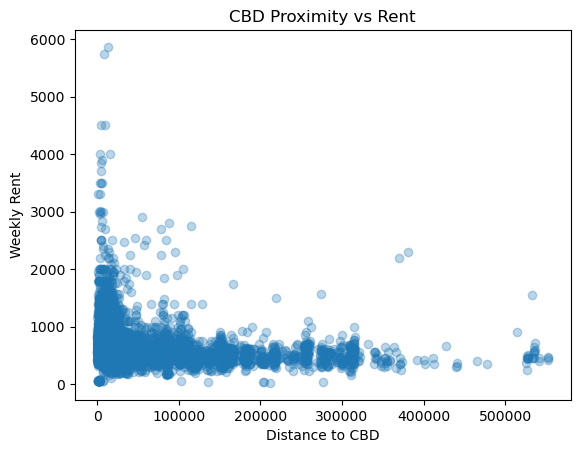

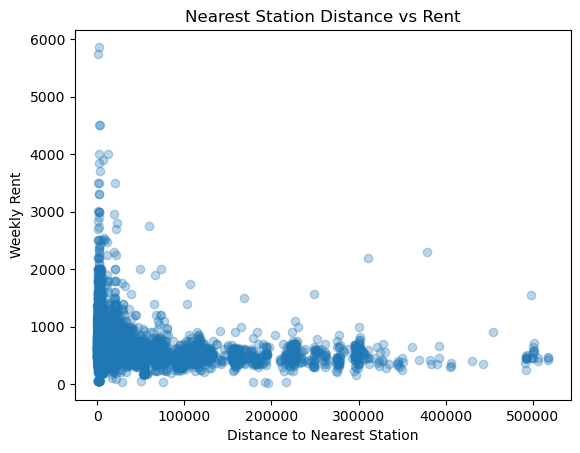

In [ ]:
# Descriptive statistics:
all_info[['weekly_rent','distance_to_nearest_station', 'distance_to_cbd']].describe()

import matplotlib.pyplot as plt

# CBD Proximity vs Rent (Scatterplot)
plt.scatter(all_info['distance_to_cbd'], all_info['weekly_rent'], alpha=0.3)
plt.xlabel("Distance to CBD")
plt.ylabel("Weekly Rent")
plt.title("CBD Proximity vs Rent")
plt.show()

# Distance to Station vs Rent (Scatterplot)
plt.scatter(all_info['distance_to_nearest_station'], all_info['weekly_rent'], alpha=0.3)
plt.xlabel("Distance to Nearest Station")
plt.ylabel("Weekly Rent")
plt.title("Nearest Station Distance vs Rent")
plt.show()


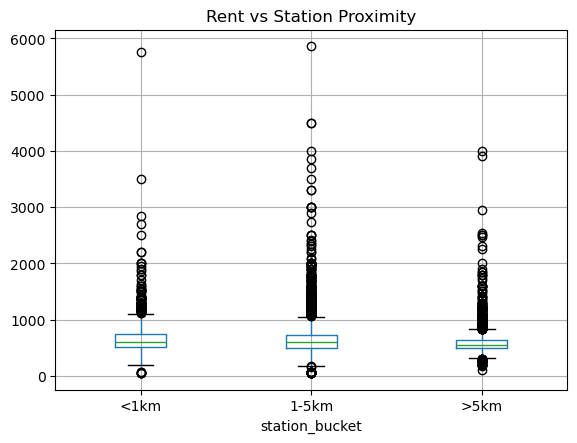

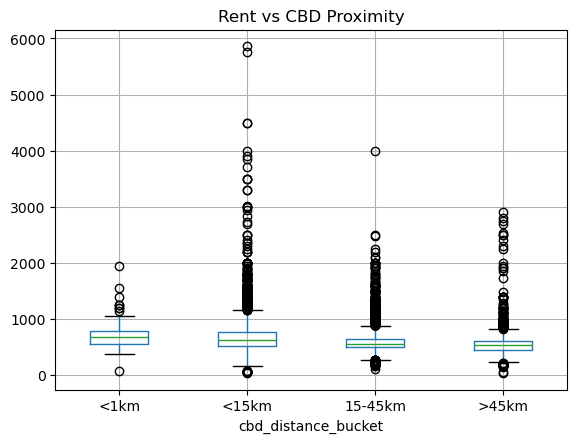

In [ ]:
# Station distances (Box Plot)
all_info['station_bucket'] = pd.cut(all_info['distance_to_nearest_station'], bins=[0,1000,5000,20000], labels=['<1km','1-5km','>5km'])
all_info.boxplot(column='weekly_rent', by='station_bucket')
plt.title("Rent vs Station Proximity")
plt.suptitle("")
plt.show()


# CBD Distances (Box Plot)
all_info['cbd_distance_bucket'] = pd.cut(all_info['distance_to_cbd'], bins=[0,1000,15000,45000,200000], labels=['<1km', '<15km','15-45km','>45km'])
all_info.boxplot(column='weekly_rent', by='cbd_distance_bucket')
plt.title("Rent vs CBD Proximity")
plt.suptitle("")
plt.show()   